# 19 May 2026 - making figures for CV paper

In [1]:

import json
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update(plt.rcParamsDefault)
with open('/data/taylor_group/levi_schult/ng15_rcparams.json', 'rb') as fin:
    plt.rcParams.update(json.load(fin))
plt.style.use('seaborn-v0_8-colorblind')


%matplotlib inline
%config InlineBackend.figure_format='retina'

## import pkls

In [2]:
# LSS all 4 year for now
cvkpc = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/kpcsn/rseed2035_zh280pc/dur12p6e7_inj_CVkpcpop1-rs2035zh280_GBpop2_rec_n_doublebrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
cvthin = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thin/dur12p6e7_inj_CVgxypop1-rs2035thin_GBpop2_rec_n_doublebrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
cvthick = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thick/dur12p6e7_inj_CVgxypop1-rs2035thick_GBpop2_rec_n_doublebrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
cvthin_stepthin = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thin/dur12p6e7_inj_CVgxypop1-rs2035thin_GBpop2_rec_n_doublebrokentruncPLpfixedgal_onestep2parfixedgalthin/plot_data.pickle', 'rb'))
cvthick_stepthick = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/thick/dur12p6e7_inj_CVgxypop1-rs2035thick_GBpop2_rec_n_onestep2parfixedgalthick_dblbrokentruncPLpfixedgal/plot_data.pickle', 'rb'))
dwdthin_dbtpl = pkl.load(open('/home/schultls/levi_schult/blip_CVs/storage/run_outputs/prod3/DBTPL_GBpop_control/dur12p6e7_inj_GBpop2_rec_n_dblbroketruncpowlawfixedgal/plot_data.pickle', 'rb'))

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/schultls/.local/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/schultls/.local/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/home/schultls/.local/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


## freq dist of CVs (kpc and full gxy)

## CV kpc & CV gxy vs control

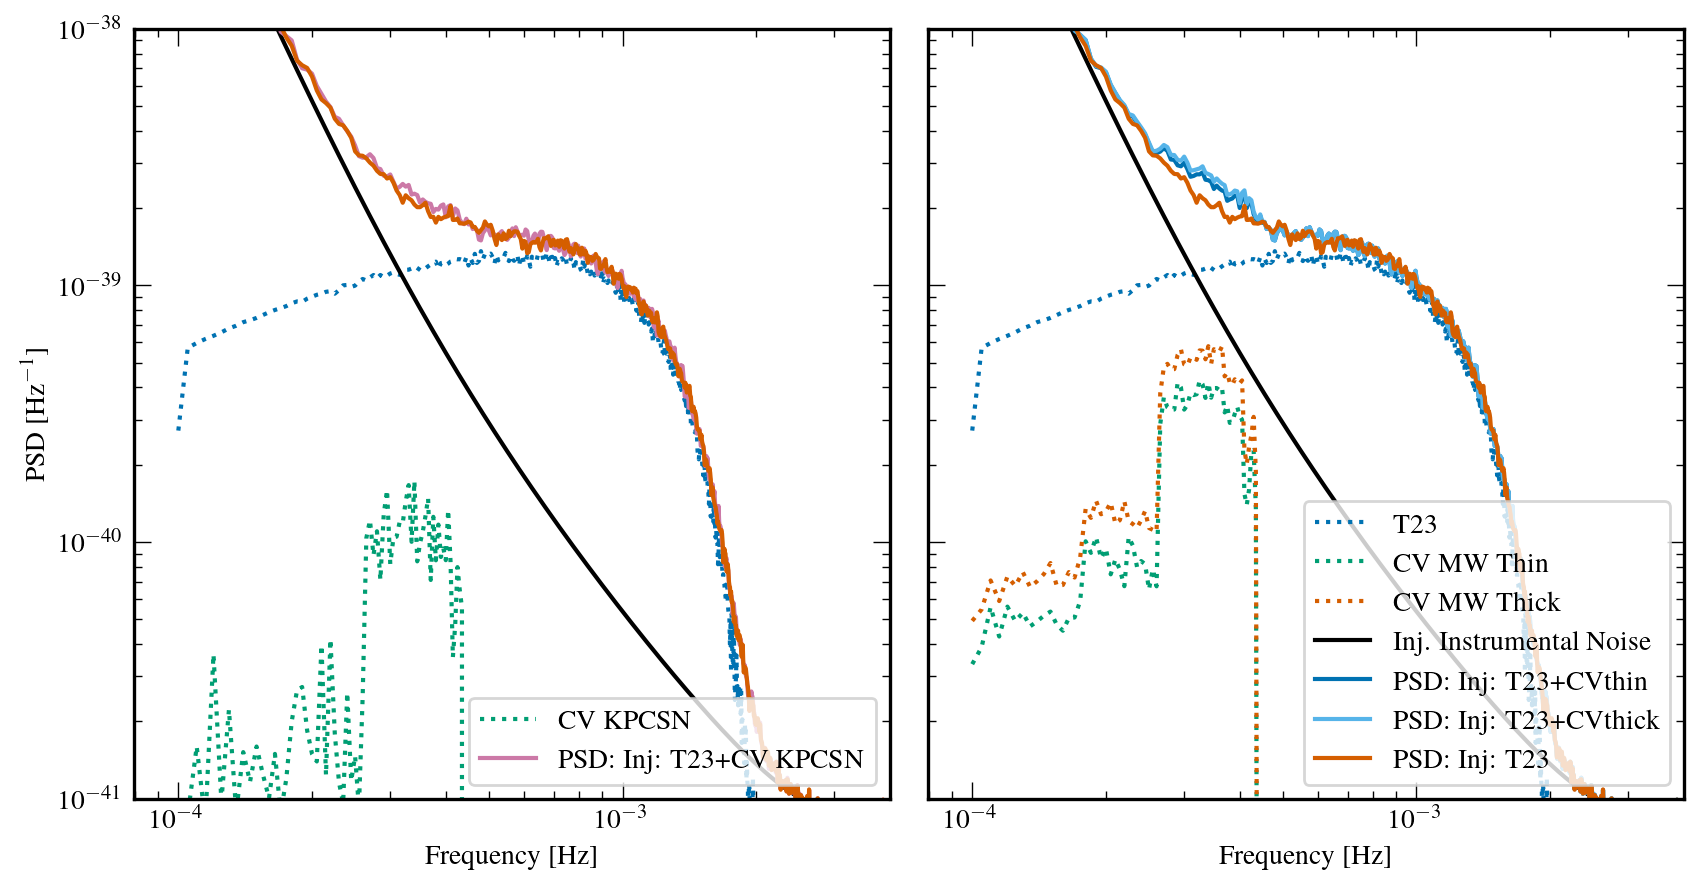

In [38]:
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True,figsize=(10, 5))


####### KPCSN COMPARISON ########
# populations.
ax[0].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], color='C0', linestyle='dotted')
ax[0].plot(cvkpc['fit_data']['fs'], cvkpc['fit_data']['det_inj']['population-1']['spec'], label='CV KPCSN', color='C1', linestyle='dotted')

# noise
ax[0].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['noise']['spec'], color='k')

# kpcsn PSD comparison
ax[0].plot(cvkpc['injspec_data']['data_psd']['psdfreqs'], cvkpc['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23+CV KPCSN', color='C3')
ax[0].plot(dwdthin_dbtpl['injspec_data']['data_psd']['psdfreqs'], dwdthin_dbtpl['injspec_data']['data_psd']['psd1'], color='C2')

####### FULL GXY COMPARISON ########
# populations.
ax[1].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0', linestyle='dotted')
ax[1].plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thin', color='C1', linestyle='dotted')
ax[1].plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_inj']['population-1']['spec'], label='CV MW Thick', color='C2', linestyle='dotted')

# noise
ax[1].plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['noise']['spec'], label='Inj. Instrumental Noise', color='k')

# MW PSD comparison
ax[1].plot(cvthin['injspec_data']['data_psd']['psdfreqs'], cvthin['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23+CVthin', color='C6')
ax[1].plot(cvthick['injspec_data']['data_psd']['psdfreqs'], cvthick['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23+CVthick', color='C5')
ax[1].plot(dwdthin_dbtpl['injspec_data']['data_psd']['psdfreqs'], dwdthin_dbtpl['injspec_data']['data_psd']['psd1'], label='PSD: Inj: T23', color='C2')


ax[0].loglog()
ax[0].set_xlim(right=4e-3)
ax[0].legend(loc='lower right', fontsize='medium')
ax[1].legend(loc='lower right', fontsize='medium')
ax[0].set_ylim(bottom=1e-41, top=1e-38)
ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'PSD [$\rm{Hz }^{-1}$]')
plt.subplots_adjust(wspace=0.05)

## Spectral recovery of DWDthin (impact of CVs)

In [3]:
cvthin_stepthin.keys()

dict_keys(['injspec_data', 'map_data', 'fit_data'])

In [54]:
cvthin_stepthin['fit_data']['det_fits'].keys()

dict_keys(['noise', 'doublebrokentruncpowerlaw_fixedgalaxy', 'onesidestep2par_fixedgalaxy'])

In [7]:
dwdthin_dbtpl['fit_data'].keys()

dict_keys(['fs', 'fs_full', 'fmin', 'fmax', 'astro_fits', 'det_fits', 'astro_inj', 'det_inj'])

In [28]:
dwdthin_dbtpl['fit_data']['det_inj']

{'noise': {'spec': Array([6.9528484e-38, 5.7596147e-38, 4.8160560e-38, ..., 3.7106383e-41,
         3.7140014e-41, 3.7172244e-41], dtype=float32)},
 'population-2': {'spec': array([2.71631641e-40, 5.70518050e-40, 5.95993304e-40, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(1981,))}}

Text(0, 0.5, 'PSD [$\\rm{Hz }^{-1}$]')

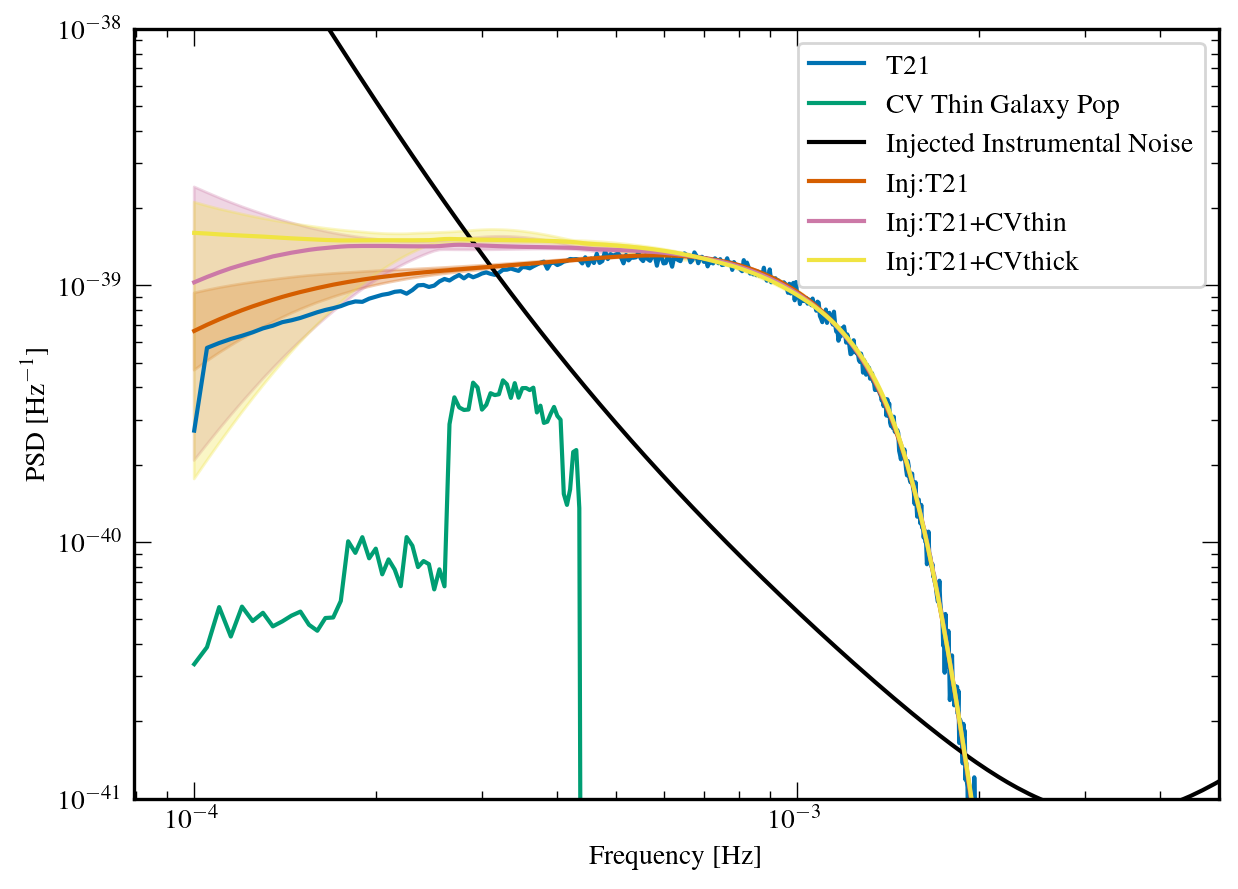

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# populations.
ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['population-2']['spec'], label='T23', color='C0')
ax.plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_inj']['population-1']['spec'], label='CV Thin Galaxy Pop', color='C1')


# noise
ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_inj']['noise']['spec'], label='Injected Instrumental Noise', color='k')

# noise recovery
# ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_fits']['noise']['median'], 
#         label='Inj:T23 - Recovered Instrumental Noise', color='k', alpha=0.5)
# ax.plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_fits']['noise']['median'], 
#         label='Inj:T23+CVthin - Recovered Instrumental Noise', color='k', linestyle='dashed')


# No CVs injected
ax.plot(dwdthin_dbtpl['fit_data']['fs'], dwdthin_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
         label='Inj:T23', color='C2')
ax.fill_between(dwdthin_dbtpl['fit_data']['fs'], 
                dwdthin_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                dwdthin_dbtpl['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C2')

# CVs thin injected
ax.plot(cvthin['fit_data']['fs'], cvthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
         label='Inj:T23+CVthin', color='C3')
ax.fill_between(cvthin['fit_data']['fs'], 
                cvthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                cvthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C3')

# CVs thick injected
ax.plot(cvthick['fit_data']['fs'], cvthick['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
         label='Inj:T23+CVthick', color='C4')
ax.fill_between(cvthick['fit_data']['fs'], 
                cvthick['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                cvthick['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C4')


ax.loglog()
ax.set_xlim(right=5e-3)
plt.legend(loc='upper right', fontsize='medium')
ax.set_ylim(bottom=1e-41, top=1e-38)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'PSD [$\rm{Hz }^{-1}$]')

## Attempts at Spectral Separation

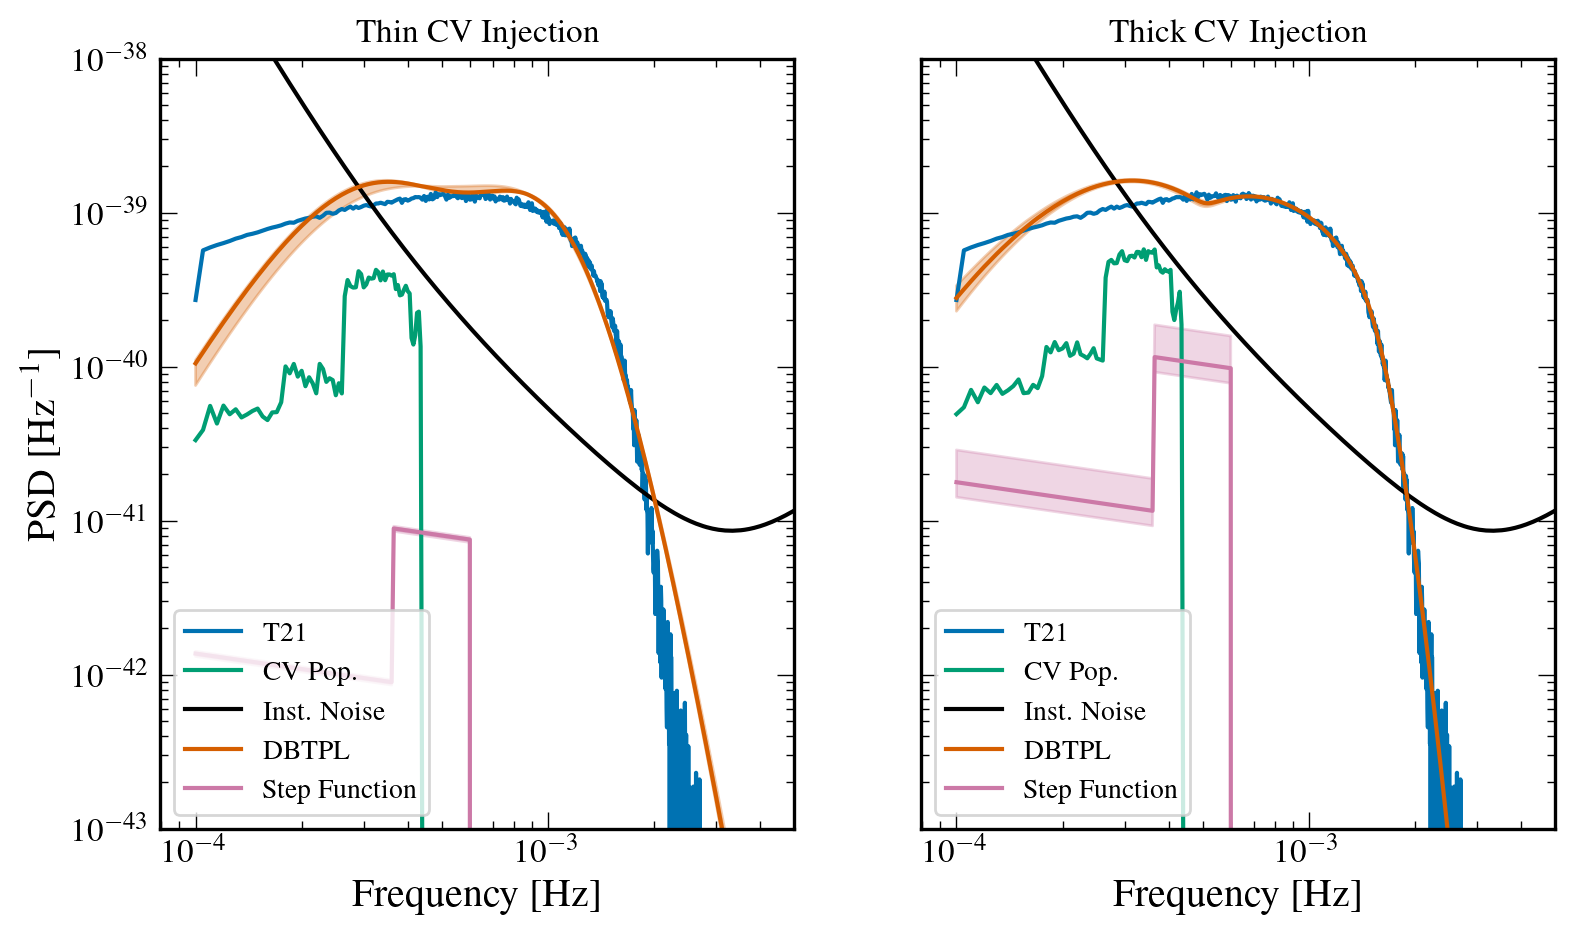

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

runs = [cvthin_stepthin, cvthick_stepthick]
radht = ['Thin', 'Thick']

for idx, run in enumerate(runs):

    # populations.
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_inj']['population-2']['spec'], label='T23')
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_inj']['population-1']['spec'], label=f'CV Pop.', color='C1')

    # noise
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_inj']['noise']['spec'], label='Inst. Noise', color='k')

    # DWD DBTPL recovery
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'],
            label=f'DBTPL', color='C2')
    ax[idx].fill_between(run['fit_data']['fs'], 
                    run['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                    run['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C2')

    # CVs thin recovered
    ax[idx].plot(run['fit_data']['fs'], run['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['median'],
            label=f'Step Function', color='C3')
    ax[idx].fill_between(run['fit_data']['fs'], 
                    run['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['lower95'], 
                    run['fit_data']['det_fits']['onesidestep2par_fixedgalaxy']['upper95'], alpha=0.3, color='C3')

    # CVs thick injected

    ax[idx].set_title(f'{radht[idx]} CV Injection', fontsize='large')
    ax[idx].loglog()
    ax[idx].legend(loc='lower left', fontsize='medium')
    ax[idx].set_xlim(right=5e-3)
    ax[idx].set_ylim(bottom=1e-43, top=1e-38)
    ax[idx].set_xlabel('Frequency [Hz]', fontsize='x-large')
    ax[idx].tick_params(axis='both', which='major', labelsize='large')


ax[0].set_ylabel(r'PSD [$\rm{Hz }^{-1}$]', fontsize='x-large')

plt.show()

In [ ]:
ax.plot(cvthin_stepthin['fit_data']['fs'], cvthin_stepthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['median'], label='CVthin:stepthin+fixgalthin', color='C2')
ax.fill_between(cvthin_stepthin['fit_data']['fs'], 
                cvthin_stepthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['lower95'], 
                cvthin_stepthin['fit_data']['det_fits']['doublebrokentruncpowerlaw_fixedgalaxy']['upper95'], alpha=0.3, color='C2')


In [ ]:
fig, ax = plt.subplots()

ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['data_psd']['psd1']), label='ASD with CVs')
ax.plot(noCV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(noCV_plot['injspec_data']['data_psd']['psd1']), label='ASD without CVs')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['noise_spectra']['noise1']), label='Instrumental Noise')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['truncatedpowerlaw4par_fixedgalaxy']['S1_gw']), label='Injected GB Spectrum')
ax.plot(CV_plot['injspec_data']['data_psd']['psdfreqs'], np.sqrt(CV_plot['injspec_data']['population']['S1_gw']), label='CV Population')

ax.loglog()
ax.set_xlim(right=3e-3)
ax.set_ylim(bottom=1e-21, top=3e-19)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(r'ASD [$\rm{Hz}^{-1/2}$]')